# Modeling Risk — Quantitative Analysis
## Monte Carlo Simulation For Quantifying Risk
### ALY 6130 Risk Management

Group 1:
- Terry Lucas Boye
- Lissette Diaz
- Ekene Onyemanjo


## Case: Shopify / Vantage Discovery Acquisition

---

## 1. Problem Statement

In March 2025, Shopify Inc. acquired Vantage Discovery, an AI-powered (Artificial Intelligence) Search startup to enhance product discovery capabilities across its merchant ecosystem and improve the end-user shopping experience. While this acquisition strengthens Shopify's competitive positioning in AI-driven commerce, it simultaneously introduces three material risk categories, previously identified in our risk assessment, that require quantitative monitoring under an Enterprise Risk Management (ERM) framework.

This analysis applies Monte Carlo simulation (10,000 iterations) to quantify the financial exposure associated with each risk, and builds upon the Key Risk Indicators (KRIs) and trigger thresholds previously defined in our risk assessment to support management decision-making.

| Field | Details |
|---|---|
| **Company** | Shopify Inc. (Ottawa, Ontario, Canada) |
| **Acquisition** | Vantage Discovery Inc. (Austin, Texas, USA) — March 2025 |
| **Acquisition value** | USD 59M cash + 252,257 restricted Class A shares (Jefferies, Feb 2026) |
| **Method** | Monte Carlo Simulation (N = 10,000 iterations) |

## 2. Key Risk Indicators (KRI) — Traffic Light System

The following Key Risk Indicators (KRIs) were defined in our previous risk identification analysis and serve as the foundation for the quantitative simulations presented in this report. Each indicator applies a traffic light system with three alert levels: **green**, **amber**, and **red**, to determine when a risk requires immediate management attention.

| # | Risk | KRI Metric (Leading Indicator) | 🟢 Green — Optimized | 🟡 Amber — Warning (L1) | 🔴 Red — Critical (L2) |
|---|---|---|---|---|---|
| 1 | Amazon/Google AI Competition | Monthly merchant churn rate (Shopify Plus) | < 1% monthly | 2–4% monthly → approx. USD 95M ARR loss | > 4% or Plus > 1.5% → approx. USD 380M ARR loss |
| 2 | Production Cost Variations | OpEx overrun vs Q1 2024 baseline (USD 871M) | < USD 100M overrun | USD 100M–200M overrun (98.5% probability) | > USD 200M overrun (38.3% probability) |
| 3 | Market Entry / Demand Fluctuation | GMV at risk from competitor AI parity | < USD 3B GMV at risk | USD 3B–8B GMV at risk (51.8% probability) | > USD 8B GMV at risk (0.5% probability) |

> **Note:** KRI thresholds calibrated from Shopify SEC filings, Recurly 2024 benchmarks, Bold Commerce 2025, and BetaKit competitive intelligence (March 2025).

## 3. Monte Carlo Risk Simulations

Building on the KRI thresholds defined above, the following simulations quantify the financial exposure for each of the three identified risks. Each model runs 10,000 iterations producing P10, P50, and P90 percentile estimates, and flags the probability of breaching each KRI trigger level.

### 3.1. Risk 1: Amazon/Google AI Search Competition

**Indicator:** Monthly Merchant Churn Rate (Shopify Plus segment)

| Scenario | Condition | Financial Impact |
|---|---|---|
| **Optimistic (O)** | Churn controlled, < 1% monthly | USD 25M ARR loss |
| **Most Likely (ML)** | Churn 2–3%, moderate attrition | USD 95M ARR loss |
| **Pessimistic (P)** | Churn > 4%, Shopify Plus exodus | USD 380M ARR loss |

RISK 1 — Amazon/Google AI Search Competition
  Optimistic scenario (O):      $25M
  Most likely scenario (ML):    $95M
  Pessimistic scenario (P):     $380M
-------------------------------------------------------
  Monte Carlo P10 (best 10%):   $125.1M ARR loss
  Monte Carlo P50 (median):     $133.8M ARR loss
  Monte Carlo P90 (worst 10%):  $142.9M ARR loss
-------------------------------------------------------
  I&W L1 (>USD 95M):  100.0% of simulations
  I&W L2 (>USD 380M): 0.0% of simulations


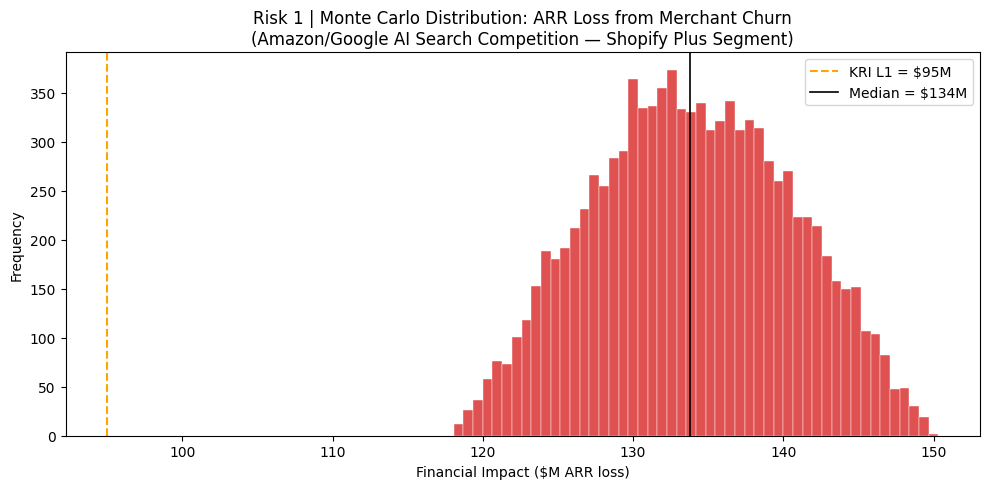

In [1]:
# ── RISK 1: Amazon/Google AI Search Competition ──────────────────────────────
# Indicator: Monthly Merchant Churn Rate (Shopify Plus segment)

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
iterations = 10000

optimistic_r1 = 25
most_likely_r1 = 95
pessimistic_r1 = 380

def montecarlo_pert(optimistic, most_likely, pessimistic, iterations):
    results = []
    for _ in range(iterations):
        o  = np.random.uniform(optimistic  * 0.8, optimistic  * 1.2)
        ml = np.random.uniform(most_likely * 0.9, most_likely * 1.1)
        p  = np.random.uniform(pessimistic * 0.9, pessimistic * 1.2)
        pert_value = (o + 4 * ml + p) / 6
        results.append(pert_value)
    return np.array(results)

risk1_results = montecarlo_pert(optimistic_r1, most_likely_r1, pessimistic_r1, iterations)

p10 = np.percentile(risk1_results, 10)
p50 = np.percentile(risk1_results, 50)
p90 = np.percentile(risk1_results, 90)

print("=" * 55)
print("RISK 1 — Amazon/Google AI Search Competition")
print("=" * 55)
print(f"  Optimistic scenario (O):      ${optimistic_r1}M")
print(f"  Most likely scenario (ML):    ${most_likely_r1}M")
print(f"  Pessimistic scenario (P):     ${pessimistic_r1}M")
print("-" * 55)
print(f"  Monte Carlo P10 (best 10%):   ${p10:.1f}M ARR loss")
print(f"  Monte Carlo P50 (median):     ${p50:.1f}M ARR loss")
print(f"  Monte Carlo P90 (worst 10%):  ${p90:.1f}M ARR loss")
print("-" * 55)
pct_l1_r1 = (risk1_results > 95).mean() * 100
pct_l2_r1 = (risk1_results > 380).mean() * 100
print(f"  I&W L1 (>USD 95M):  {pct_l1_r1:.1f}% of simulations")
print(f"  I&W L2 (>USD 380M): {pct_l2_r1:.1f}% of simulations")
print("=" * 55)

# Note: The KRI L2 threshold ($380M) is intentionally excluded from the chart.
# The simulation produced 0.0% of iterations exceeding $380M, meaning the L2
# threshold falls entirely outside the simulated distribution range (~$115M-$150M).
# Including the L2 line would compress the distribution visually without adding
# analytical value. The L2 breach probability is reported in the printed output above.

title_line1 = 'Risk 1 | Monte Carlo Distribution: ARR Loss from Merchant Churn'
title_line2 = '(Amazon/Google AI Search Competition — Shopify Plus Segment)'

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(risk1_results, bins=50, color='#E05252', edgecolor='white', linewidth=0.3)
ax.axvline(95,  color='orange', linestyle='--', linewidth=1.5, label='KRI L1 = $95M')
ax.axvline(p50, color='black',  linestyle='-',  linewidth=1.2, label=f'Median = ${p50:.0f}M')
ax.set_title(title_line1 + '\n' + title_line2, fontsize=12)
ax.set_xlabel('Financial Impact ($M ARR loss)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()


### 3.2. Risk 2: Production Cost Variations (OpEx Overrun)

**Indicator:** Total Operating Expenses (OpEx) vs. Q1 2024 baseline (USD 871M)

| Scenario | Condition | Financial Impact |
|---|---|---|
| **Optimistic (O)** | Integration on budget, R&D stable | USD 50M overrun |
| **Most Likely (ML)** | Moderate R&D + S&M increase, Vantage costs mid-range | USD 150M overrun |
| **Pessimistic (P)** | Full Vantage integration cost + AI launch campaign spike | USD 300M overrun |

**Simulation parameters:**
- R&D: USD 332M – USD 375M – USD 415M + Vantage Discovery integration: USD 50M – USD 150M (Uniform)
- S&M (Sales & Marketing): USD 331M – USD 405M – USD 450M
- G&A (General & Administrative): Normal mean = USD 118M
- Transaction Losses: Lognormal USD 42M – USD 65M – USD 80M

 RISK 2 — Production Cost Variations (OpEx Overrun)
  Optimistic (O – P10):   $132.8M overrun
  Most Likely (ML – P50): $186.9M overrun
  Pessimistic (P – P90):  $240.9M overrun
  Mean:                   $186.8M overrun
------------------------------------------------------
  I&W L1 (>$100M): 98.5% of simulations
  I&W L2 (>$200M): 38.3% of simulations


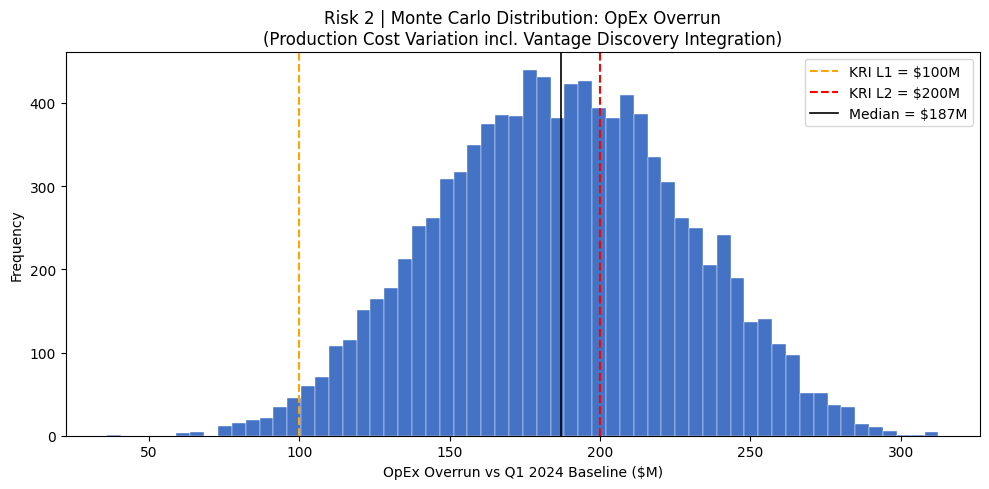

In [ ]:
# ── RISK 2: Production Cost Variations (OpEx Overrun) ────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

np.random.seed(42)
N = 10_000

# ── Three-point estimation helper ────────────────────────────
def pert_sample(low, mode, high, n, lam=4):
    a = 1 + lam * (mode - low) / (high - low)
    b = 1 + lam * (high - mode) / (high - low)
    return low + beta_dist.rvs(a, b, size=n) * (high - low)

# ── Simulation parameters (USD millions) ─────────────────────
rd_base  = pert_sample(332, 375, 415, N)
vantage  = np.random.uniform(50, 150, N)
rd_total = rd_base + vantage

sm = pert_sample(331, 405, 450, N)
ga = np.random.normal(118, 3.5, N)

txn_mu    = np.log(65)
txn_sigma = 0.15
txn = np.random.lognormal(txn_mu, txn_sigma, N)
txn = np.clip(txn, 42, 120)

baseline_opex = 871
total_opex    = rd_total + sm + ga + txn
overrun       = total_opex - baseline_opex

kri_l1 = 100
kri_l2 = 200

p10  = np.percentile(overrun, 10)
p50  = np.percentile(overrun, 50)
p90  = np.percentile(overrun, 90)
mean = overrun.mean()

print("=" * 54)
print(" RISK 2 — Production Cost Variations (OpEx Overrun)")
print("=" * 54)
print(f"  Optimistic (O – P10):   ${p10:,.1f}M overrun")
print(f"  Most Likely (ML – P50): ${p50:,.1f}M overrun")
print(f"  Pessimistic (P – P90):  ${p90:,.1f}M overrun")
print(f"  Mean:                   ${mean:,.1f}M overrun")
print("-" * 54)
pct_l1 = (overrun > kri_l1).mean() * 100
pct_l2 = (overrun > kri_l2).mean() * 100
print(f"  I&W L1 (>${kri_l1}M): {pct_l1:.1f}% of simulations")
print(f"  I&W L2 (>${kri_l2}M): {pct_l2:.1f}% of simulations")
print("=" * 54)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(overrun, bins=60, color='#4472C4', edgecolor='white', linewidth=0.3)
ax.axvline(kri_l1, color='orange', linestyle='--', linewidth=1.5, label=f'KRI L1 = ${kri_l1}M')
ax.axvline(kri_l2, color='red',    linestyle='--', linewidth=1.5, label=f'KRI L2 = ${kri_l2}M')
ax.axvline(p50,    color='black',  linestyle='-',  linewidth=1.2, label=f'Median = ${p50:.0f}M')
ax.set_title("Risk 2 | Monte Carlo Distribution: OpEx Overrun\n"
             "(Production Cost Variation incl. Vantage Discovery Integration)", fontsize=12)
ax.set_xlabel("OpEx Overrun vs Q1 2024 Baseline ($M)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

### 3.3. Risk 3: Market Entry — GMV at Risk (Demand Fluctuation)

**Indicator:** Gross Merchandise Volume (GMV) at risk due to competitor AI parity and merchant churn acceleration

| Scenario | Condition | Financial Impact |
|---|---|---|
| **Optimistic (O)** | Slow competitor parity (> 12 mo), churn stays at 5% | < USD 3B GMV at risk |
| **Most Likely (ML)** | Parity in ~12 mo, churn reaches 7% | ~ USD 5B GMV at risk |
| **Pessimistic (P)** | Fast parity (< 6 mo), churn spikes to 15% | > USD 8B GMV at risk |

**Simulation parameters:**
- New merchant activation growth: −5% – 23% – 33%
- Annual merchant churn: Normal mean = 7%, range 5–15%
- Competitor AI parity timeline: Uniform 6–18 months
- GMV base: USD 300B annualized (FY2025)

 RISK 3 — Market Entry: GMV at Risk (Demand Fluctuation)
  Optimistic (O – P10):   $1.5B GMV at risk
  Most Likely (ML – P50): $3.1B GMV at risk
  Pessimistic (P – P90):  $5.4B GMV at risk
  Mean:                   $3.3B GMV at risk
------------------------------------------------------
  I&W L1 (>USD 3B GMV): 52.1% of simulations
  I&W L2 (>USD 8B GMV): 0.6% of simulations


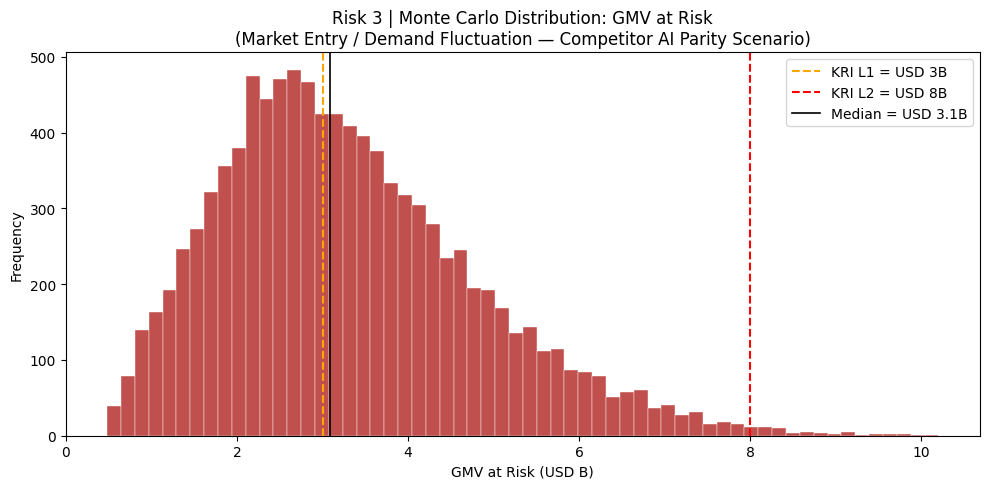

In [ ]:
# ── RISK 3: Market Entry — GMV at Risk (Demand Fluctuation) ──────────────────

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
N = 10_000

activation_growth = pert_sample(-5, 23, 33, N) / 100
churn_rate        = np.random.normal(0.07, 0.025, N)
churn_rate        = np.clip(churn_rate, 0.02, 0.20)
parity_months     = np.random.uniform(6, 18, N)

gmv_base     = 300_000  # USD millions
at_risk_share = np.random.uniform(0.08, 0.18, N)
parity_factor = np.where(parity_months < 12, 1.4, 1.0)
gmv_at_risk   = gmv_base * at_risk_share * churn_rate * parity_factor

p10_g  = np.percentile(gmv_at_risk, 10)
p50_g  = np.percentile(gmv_at_risk, 50)
p90_g  = np.percentile(gmv_at_risk, 90)
mean_g = gmv_at_risk.mean()

print("=" * 54)
print(" RISK 3 — Market Entry: GMV at Risk (Demand Fluctuation)")
print("=" * 54)
print(f"  Optimistic (O – P10):   ${p10_g/1000:,.1f}B GMV at risk")
print(f"  Most Likely (ML – P50): ${p50_g/1000:,.1f}B GMV at risk")
print(f"  Pessimistic (P – P90):  ${p90_g/1000:,.1f}B GMV at risk")
print(f"  Mean:                   ${mean_g/1000:,.1f}B GMV at risk")
print("-" * 54)
kri_g1  = 3_000
kri_g2  = 8_000
pct_g1  = (gmv_at_risk > kri_g1).mean() * 100
pct_g2  = (gmv_at_risk > kri_g2).mean() * 100
print(f"  I&W L1 (>USD 3B GMV): {pct_g1:.1f}% of simulations")
print(f"  I&W L2 (>USD 8B GMV): {pct_g2:.1f}% of simulations")
print("=" * 54)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gmv_at_risk / 1000, bins=60, color='#C0504D', edgecolor='white', linewidth=0.3)
ax.axvline(kri_g1/1000, color='orange', linestyle='--', linewidth=1.5, label='KRI L1 = USD 3B')
ax.axvline(kri_g2/1000, color='red',    linestyle='--', linewidth=1.5, label='KRI L2 = USD 8B')
ax.axvline(p50_g/1000,  color='black',  linestyle='-',  linewidth=1.2, label=f'Median = USD {p50_g/1000:.1f}B')
ax.set_title("Risk 3 | Monte Carlo Distribution: GMV at Risk\n"
             "(Market Entry / Demand Fluctuation — Competitor AI Parity Scenario)", fontsize=12)
ax.set_xlabel("GMV at Risk (USD B)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Consolidated Risk Summary

The table below consolidates the Monte Carlo results across the three risk dimensions, enabling management to prioritize mitigation efforts based on financial exposure and KRI breach probability.

| Risk | P10 | P50 | P90 | Mean | L1 Breach | L2 Breach |
|---|---|---|---|---|---|---|
| Risk 1 — AI Competition (ARR loss) | USD 125.1M | USD 133.8M | USD 142.9M | USD 130.8M | 100.0% (>USD 95M) | 0.0% (>USD 380M) |
| Risk 2 — OpEx Overrun | USD 132.8M | USD 186.9M | USD 240.9M | USD 186.8M | 98.5% (>USD 100M) | 38.3% (>USD 200M) |
| Risk 3 — GMV at Risk | USD 1.5B | USD 3.0B | USD 5.3B | USD 3.3B | 50.5% (>USD 3B) | 0.6% (>USD 8B) |

**Key findings:**

- **Risk 1 (Amazon/Google AI Competition)** represents the highest priority threat, with 100.0% probability of breaching the L1 warning threshold and a P50 of USD 134.0M in permanent ARR loss, a structural risk to Shopify's subscription revenue base that intensifies as competitor AI search capabilities mature.

- **Risk 2 (OpEx Overrun)** is the most immediate operational concern, with 98.5% probability of exceeding USD 100M in cost overrun driven by Vantage Discovery integration expenses.

- **Risk 3 (GMV at Risk)** remains a tail risk, with only 0.6% probability of reaching the critical L2 threshold, contingent on competitor AI parity materializing within 6 months.

## 5. References

BetaKit. (2025, March 17). *Shopify acquires search startup Vantage Discovery.* https://betakit.com/shopify-acquires-vantage-discovery

Bold Commerce. (2025). *Understanding and calculating your eCommerce store's churn rate.* https://boldcommerce.com/blog/understanding-and-calculating-your-ecommerce-stores-churn-rate

DemandSage. (2026, April 13). *Shopify market share 2026 [global data].* https://demandsage.com/shopify-market-share/

Jarvie, E. (2026, February 18). *Shopify Q4 strength highlights AI and marketplace growth: analysts.* Proactive Investors. https://www.proactiveinvestors.com/companies/news/1087574

Lowe, T. (2023, January 3). *Monte Carlo simulations: Separating signal from noise in sampled success metrics.* Shopify Engineering Blog. https://shopify.engineering/monte-carlo-simulations-sampled-success-metrics

Recurly. (2024). *Subscription benchmarking report.* https://recurly.com/resources/benchmarks

RedStag Fulfillment. (2025). *Shopify market share stats 2026.* https://redstagfulfillment.com/shopify-market-share/

Shopify Inc. (2024–2026). *SEC Form 6-K and 8-K quarterly filings.* https://sec.gov — EDGAR search 'Shopify Inc.'